In [ ]:
import os
import math
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from graphcast.model_utils import stacked_to_dataset
from graphcast.losses import normalized_latitude_weights
from graphufs.stacked_utils import get_channel_index
from graphufs.datasets import Dataset
from prototypes.ocn_only.emulator import OcnEvaluator, OcnTrainer

In [ ]:
plt.style.use("graphufs.plotstyle")

In [ ]:
def persistence_fcast(model_type:str, prototype:str, eval_dates:list[str], num_missing_samples:int, fcast_nhours="240h"):

    #### SETUP ####
    emulator = OcnEvaluator(prototype)
    preserved_dims = ("batch", "lat", "lon")

    #### LOAD AND PREPARE THE STACKED DATA ####
    # read in the validation data
    valid_dir = f"{emulator.local_store_path}/validation"
    validation_inputs = xr.open_zarr(f"{valid_dir}/inputs.zarr")["inputs"] # (sample, lat, lon, channels)

    # Calculate the date ranges and find the integer indices for slicing
    validation_datetime = pd.date_range(
        start=pd.to_datetime(emulator.validation_dates[0]),
        end=(pd.to_datetime(emulator.validation_dates[1]) - 
             pd.Timedelta(emulator.delta_t_model)) - num_missing_samples*pd.Timedelta(emulator.delta_t_data),
        freq=pd.Timedelta(emulator.delta_t_data),
        inclusive="both",
    )
    
    # check the length of the validation dataset = validation datetime
    assert len(validation_datetime)==validation_inputs.sizes["sample"], \
    f"Error: Length of the time stamp vector and validation inputs did not match: {len(validation_datetime)}, {validation_inputs.sizes['sample']}"

    idx_start = validation_datetime.get_loc(pd.to_datetime(eval_dates[0]))
    idx_end = validation_datetime.get_loc(pd.to_datetime(eval_dates[1]))

    # Select the evaluation data and rename 'sample' to 'batch' for consistency
    eval_inputs = validation_inputs.sel(sample=slice(idx_start, idx_end, emulator.sample_stride)
    ).rename({"sample": "batch"}) # (batch=292, lat, lon, channels)

    # get the datetime vector corresponding to the evaluation data
    eval_datetime = pd.date_range(
        start=pd.to_datetime(eval_dates[0]),
        end=pd.to_datetime(eval_dates[1]),
        freq=pd.Timedelta(emulator.delta_t_data)*emulator.sample_stride,
        inclusive="both",
    )
    
    # assert the lengths of the eval datetime vector and the eval dataset
    assert len(eval_datetime)==eval_inputs.sizes["batch"], \
    f"Error: Length of the eval datetime vector and eval inputs did not match:" \
    f"{len(eval_datetime)}, {eval_inputs.sizes['batch']}"

    #### PREPARE THE TEMPLATE DATASET ####
    tds = Dataset(emulator, mode="training")
    xinputs, xtargets, _ = tds.get_xarrays(0)
    meta_xinputs = get_channel_index(xinputs)

    for variable in xinputs.data_vars:
        dims_to_ensure = preserved_dims #tuple(d for d in preserved_dims if d != "batch")
        dims_not_present = [d for d in dims_to_ensure if d not in xinputs[variable].dims]
        for dimen in dims_not_present:
            xinputs[variable] = xinputs[variable].expand_dims(dim={dimen:eval_inputs.coords[dimen]})
        # make sure that the batch dimension has the same size in both datasets. Actually all
        # preserved dims must have the same size in both.
        if xinputs.sizes["batch"] != eval_inputs.sizes["batch"]:
            xinputs = xinputs.reindex({"batch":eval_inputs.coords["batch"]}, method="pad")
        xinputs[variable] = xinputs[variable].transpose("batch", ..., "lat", "lon")

    #### UNSTACK VALIDATION DATA ####
    # Only consider the input channels, not forcing. Note that xinputs would not have
    # forcing channels appended at the end. Just choose the inputs because the mapping
    # is only for inputs and this is what we need essentially.
    eval_inputs = eval_inputs.isel(channels=slice(None, len(meta_xinputs)))

    # Unstack the data by passing the underlying .variable object
    eval_inputs_unstacked = stacked_to_dataset(eval_inputs.variable, 
                                               xinputs, preserved_dims=preserved_dims)
    
    # now return the persistence in the same form as targets
    ds_persistence_fcast = xr.Dataset()
    
    # lead_time dimension
    start = emulator.delta_t_model                        # Start at delta_t_model duration
    end = pd.Timedelta(int(fcast_nhours[:-1]), unit="h")  # End at nhours duration

    # Generate the TimedeltaIndex 
    intervals = pd.timedelta_range(start=start, end=end, freq=emulator.delta_t_model)

    for variable in xtargets.data_vars:
        var = eval_inputs_unstacked[variable].isel(time=-1, drop=True)
        var = var.rename(batch="time").assign_coords(time=eval_datetime)
        var = var.expand_dims(dim={"lead_time":intervals})
        ds_persistence_fcast[variable] = var.transpose("time", ..., "lead_time", "lat", "lon")
    
    return ds_persistence_fcast

In [ ]:
def climatology_fcast(model_type:str, prototype:str, eval_dates:list[str], fcast_nhours="240h"):

    clima_unstacked = climatology(model_type, prototype)
    
    # now return the persistence in the same form as targets
    ds_clima_fcast = xr.Dataset()
    
    # lead_time dimension
    start = emulator.delta_t_model                        # Start at delta_t_model duration
    end = pd.Timedelta(int(fcast_nhours[:-1]), unit="h")  # End at nhours duration

    # Generate the TimedeltaIndex 
    intervals = pd.timedelta_range(start=start, end=end, freq=emulator.delta_t_model)

    # get the datetime vector corresponding to the evaluation data
    eval_datetime = pd.date_range(
        start=pd.to_datetime(eval_dates[0]),
        end=pd.to_datetime(eval_dates[1]) - pd.Timedelta(emulator.delta_t_model),
        freq=pd.Timedelta(emulator.delta_t_data)*emulator.sample_stride,
        inclusive="both",
    )
    
    for variable in xtargets.data_vars:
        var = clima_unstacked[variable]
        var = var.expand_dims(dim={"time": eval_datetime})
        var = var.expand_dims(dim={"lead_time":intervals})
        ds_clima_fcast[variable] = var.transpose("time", ..., "lead_time", "lat", "lon")
    
    return ds_clima_fcast

In [ ]:
def climatology(model_type:str, prototype:str):

    #### SETUP ####
    ocn_only_home = f"/global/homes/n/nagarwal/graph-ufs/prototypes/{model_type}"
    config_trainer_path = f"{ocn_only_home}/{prototype}/config.yaml"
    emulator = OcnTrainer(config=config_trainer_path)
    preserved_dims = ("lat", "lon")

    #### LOAD AND PREPARE THE STACKED DATA ####
    # read in the training data
    train_dir = f"{emulator.local_store_path}/training"
    training_targets = xr.open_zarr(f"{train_dir}/targets.zarr")["targets"] # (sample, lat, lon, channels)

    # climatology
    climatology = training_targets.mean(dim="sample") # (lat, lon, channels)

    #### PREPARE THE TEMPLATE DATASET ####
    tds = Dataset(emulator, mode="training")
    xinputs, xtargets, _ = tds.get_xarrays(0)

    #### UNSTACK CLIMATOLOGY ####
    clima_unstacked = stacked_to_dataset(climatology.variable, 
                                         xtargets.isel(batch=0, time=0, drop=True), 
                                         preserved_dims=preserved_dims)
    return clima_unstacked

In [ ]:
def load_model_prediction(config, eval_dates):
    """Loads prediction data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
    
    if pred_prefix == "persistence":
        num_missing_samples = config["num_missing_samples"] if config["num_missing_samples"] else 0
        return persistence_fcast(
            config["model_type"], config["run"], eval_dates, 
            num_missing_samples=num_missing_samples,
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "climatology":
        return climatology_fcast(
            config["model_type"], config["run"], eval_dates, 
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "graphufs":
        infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
        location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
        fname = f"{location}/{config['pred_prefix'].lower()}.{config['duration']}.zarr"
        model_pred = xr.open_zarr(fname)
        return model_pred.sel(time=slice(eval_dates[0], eval_dates[1]))
    
    else:
        raise ValueError(f"Unknown model type: {pred_prefix}")

In [ ]:
def calculate_metrics_for_model(model_pred, ref_truth, clima):
    """
    Calculates sq_error, abs_error, and ACC for a given model against a truth reference.
    """
    # Create a land/sea mask based on the salinity field at the first time step
    mask = xr.where(ref_truth.so.isel(time=0, lead_time=0) == 0, 0, 1)
    
    sq_error_vars = {}
    abs_error_vars = {}
    acc_vars = {}
    
    # Pre-calculate reference anomaly
    reference_anomaly_all = ref_truth - clima

    for var in model_pred.data_vars:
        # Determine the correct mask to use for this variable (with or without depth)
        current_mask = mask if "z_l" in model_pred[var].dims else mask.isel(z_l=0)
        
        # Compute error and apply mask
        error = (model_pred[var] - ref_truth[var]) * current_mask
        
        sq_error_vars[var] = error**2
        abs_error_vars[var] = abs(error)
        
        # Calculate anomalies using the masked data
        forecast_anomaly = (model_pred[var] - clima[var]) * current_mask
        reference_anomaly = reference_anomaly_all[var] * current_mask
        
        # Calculate Anomaly Correlation Coefficient
        acc_vars[var] = xr.corr(
            forecast_anomaly, 
            reference_anomaly, 
            dim=("lat", "lon")
        ).compute()
        
    return sq_error_vars, abs_error_vars, acc_vars

In [ ]:
def calculate_rmse(sqerr_da, apply_weighting=False, depth_level=0):
    """
    Calculates the Root Mean Squared Error from a squared error DataArray.
    
    This function correctly preserves the 'time' or 'init_time' dimension,
    which is necessary for plotting confidence intervals.
    """
    # Select the specified depth level if the dimension exists
    if "z_l" in sqerr_da.dims:
        sqerr_da = sqerr_da.isel(z_l=depth_level)
    
    # Apply latitude weighting if requested
    if apply_weighting:
        # Assuming you have a function `normalized_latitude_weights`
        weights = normalized_latitude_weights(sqerr_da)
        sqerr_da = sqerr_da * weights.astype(sqerr_da.dtype)
    
    # Identify dimensions to average over (all except lead_time and time)
    # The 'time' dimension (or 'init_time') holds the samples for the CI.
    dims_to_avg = [dim for dim in sqerr_da.dims if dim not in ["lead_time", "time"]]
    
    # Calculate the mean over spatial dimensions and take the square root
    rmse_da = np.sqrt(sqerr_da.mean(dim=dims_to_avg))
    
    return rmse_da

In [ ]:
def calculate_mae(abserr_da, apply_weighting=False, depth_level=0):
    """
    Calculates the Mean Absolute Error from an absolute error DataArray.
    
    This function preserves the 'time' or 'init_time' dimension,
    which is necessary for plotting confidence intervals.
    """
    # Select the specified depth level if the dimension exists
    if "z_l" in abserr_da.dims:
        abserr_da = abserr_da.isel(z_l=depth_level)
    
    # Apply latitude weighting if requested
    if apply_weighting:
        # Assuming you have a function `normalized_latitude_weights`
        weights = normalized_latitude_weights(abserr_da)
        abserr_da = abserr_da * weights.astype(abserr_da.dtype)
    
    # Identify dimensions to average over (all except lead_time and time)
    dims_to_avg = [dim for dim in abserr_da.dims if dim not in ["lead_time", "time"]]
    
    # Calculate the mean over spatial dimensions
    mae_da = abserr_da.mean(dim=dims_to_avg)
    
    return mae_da

In [ ]:
# ---- Meta and Model Configs ----
TRUTHS = ["Replay"]
EVALUATION_DATES = ("2022-01-01T00", "2022-12-31T18")
FIG_DIR = os.path.join(os.getcwd(), "figures")
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"

MODELS_CONFIG = [
    {
        "name": "Emulator-24h-MSE",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-mse"
    },
    {
        "name": "Emulator-24h-Maha",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R8",
        "expt": "T2M",
        "pred_prefix": "graphufs",
        "timestep": "24h",
        "duration": "960h",
        "description": "24hour-maha"
    },
    {
        "name": "Persistence-24h",
        "type": "persistence",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "",
        "pred_prefix": "persistence",
        "timestep": "24h",
        "duration": "240h",
        "description": "persistence",
        "num_missing_samples": 3,
    }
]

# Squared Error, Absolute Error, ACC

In [ ]:
# ---- Main computation block ----
# Initialize dictionaries to store all results
all_sq_error = {}
all_abs_error = {}
all_acc = {}

print("Loading climatology data...")
clima = climatology("ocn_only", "R5").load() 
print("Climatology loaded!!")
    
# Main loop over models
for model_config in MODELS_CONFIG:
    model_name = model_config["name"]
    print(f"\nProcessing Model: {model_name}")
        
    all_sq_error[model_name] = {}
    all_abs_error[model_name] = {}
    all_acc[model_name] = {}
        
    # Load the model prediction data once
    model_pred = load_model_prediction(model_config, EVALUATION_DATES)
        
    # Loop over the truth references for this model
    for truth_name in TRUTHS:
        print(f"Comparing against truth: {truth_name} ...")
            
        # Construct the path to the truth data
        if model_config["type"] in ["persistence", "climatology"]:
            # Logic to find the corresponding replay file for baselines
            run = "R5" if model_config['timestep'] == "24h" else "R4"
            expt = "T1M" if model_config['timestep'] == "24h" else "T3M"
            duration = "240h"
            location = os.path.join(SCRATCH_DIR, model_config["model_type"], run, f"inference_{expt}/validation/")
            fname = f"{location}/replay.{duration}.zarr"
        else:
            infer_dir = f"inference_{model_config['expt']}" if model_config["expt"] else "inference"
            location = os.path.join(SCRATCH_DIR, model_config['model_type'], model_config['run'], f"{infer_dir}/validation/")
            fname = f"{location}/{truth_name.lower()}.{model_config['duration']}.zarr"

        ref_truth = xr.open_zarr(fname)
            
        # Calculate all metrics for this model against this truth
        sq_err, abs_err, acc_val = calculate_metrics_for_model(model_pred, ref_truth, clima)
            
        # Store results
        all_sq_error[model_name][truth_name] = sq_err
        all_abs_error[model_name][truth_name] = abs_err
        all_acc[model_name][truth_name] = acc_val

print("\n --- Metric calculation complete!! ---")

## Plotting

In [ ]:
def plot_error_vs_leadtime(ax, 
                          da: xr.DataArray, 
                          var_name: str = None, 
                          unit: str = None, 
                          timestep: str = "6h", 
                          forecast_days: int = 10, 
                          label: str = "",
                          ytitle: str = "RMSE",
                          vmin: float = None,
                          vmax: float = None,
                          show_title: bool = True,
                          apply_latitude_weighting: bool = True):
    """
    Plot RMSE vs lead_time for a 2D variable.

    Parameters:
    - ax: plotting axis
    - da: xarray.DataArray with dimension ("lead_time",)
    - var_name: name of the variable
    - unit: unit of the variable
    - timestep: time step of the forecast (must be in hours)
    - forecast_days: number of days of forecasts
    - label: label to use in legend
    - vmin, vmax: RMSE bounds
    """
    # convert lead time to hours/days
    lead_time_hours = da["lead_time"].values / np.timedelta64(1, "h")
    lead_time_days = lead_time_hours / 24

    # subsample to the end of every day
    steps_per_day = int(24 / int(timestep[:-1])) 
    ts_to_plot = np.arange(steps_per_day-1, forecast_days*steps_per_day, steps_per_day)

    # get values to plot
    values = da.values[ts_to_plot]
    days = lead_time_days[ts_to_plot]

    # plot
    ax.plot(days, values, linewidth=2, label=label, marker='o', color=color)

    # vmin/vmax
    if vmin and vmax:
        ax.set_ylim(vmin, vmax)

    # axis labels
    xlabel = f"Forecast Lead Time [days]"
    ylabel = f"{ytitle} [{unit}]" if unit else f"{ytitle} [{units[var_name]}]"
    if apply_latitude_weighting:
        ylabel = f"LW-{ylabel}"
    ax.set_xlabel(xlabel, fontsize=12,)
    ax.set_ylabel(ylabel, fontsize=12,)

    # axis ticks
    ax.tick_params(axis="x", labelsize=12,)
    ax.tick_params(axis="y", labelsize=12,)

    # axis grid
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    # title
    if show_title:
        ax.set_title(f"{var_name}", fontsize=14,)
    
    return ax

In [ ]:
def plot_error_vs_leadtime_seaborn(
    ax,
    da: xr.DataArray,
    var_name: str = None,
    unit: str = None,
    timestep: str = "6h",
    forecast_days: int = 10,
    label: str = "",
    ytitle: str = "RMSE",
    vmin: float = None,
    vmax: float = None,
    show_title: bool = True,
    apply_latitude_weighting: bool = True,
):
    """
    Plot RMSE vs lead_time using Seaborn with a 95% CI over the init time.

    Parameters:
    - ax: plotting axis
    - da: xarray.DataArray with at dimensions ("init_time", "lead_time").
    - var_name: name of the variable
    - unit: unit of the variable
    - timestep: Time step of the forecast (e.g., "6h", "12h").
    - forecast_days: Number of forecast days to consider.
    - label: label to use in legend
    - vmin, vmax: y-axis bounds for RMSE
    - show_title: whether to display the plot title
    - apply_latitude_weighting: whether to add "LW" prefix to y-label
    """
    # --- 1. Data Preparation ---
    # Convert lead time from timedelta to hours
    lead_time_hours = da['lead_time'].values / np.timedelta64(1, 'h')
    
    # Convert the xarray.DataArray to a long-form pandas.DataFrame
    df = da.to_dataframe(name='rmse').reset_index()
    # Add a column for lead time in hours for easier filtering
    df['lead_time_hours'] = df['lead_time'].dt.total_seconds() / 3600

    # --- 2. Subsampling Logic ---
    # Calculate the number of forecast steps per day
    timestep_hours = int(timestep[:-1])
    steps_per_day = int(24 / timestep_hours)

    # Create a list of the lead time hours that correspond to the end of each day
    # e.g., for 6h steps: 24h, 48h, 72h...
    hours_to_plot = [d * 24 for d in range(1, forecast_days + 1)]
    
    # Filter the DataFrame to only include these specific lead times
    df_subsampled = df[df['lead_time_hours'].isin(hours_to_plot)].copy()
    
    # Add a 'lead_time_days' column for plotting
    df_subsampled['lead_time_days'] = df_subsampled['lead_time_hours'] / 24

    # --- 3. Plotting with Seaborn ---
    # Use the subsampled DataFrame. Add markers to make the points clear.
    sns.lineplot(
        data=df_subsampled,
        x='lead_time_days',
        y='rmse',
        ax=ax,
        label=label,
        linewidth=2,
        errorbar=("ci", 95),
        marker='o', # Added a marker to highlight the daily points
        markersize=8
    )
    
    # --- 4. Customizing the Plot ---
    # vmin/vmax
    if vmin is not None and vmax is not None:
        ax.set_ylim(vmin, vmax)

    # axis labels
    xlabel = "Forecast Lead Time [days]"
    ylabel = f"{ytitle} [{unit}]" if unit else ytitle
    if apply_latitude_weighting:
        ylabel = f"LW-{ylabel}"
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    # axis ticks
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    # Ensure ticks are integers from 1 to forecast_days
    ax.set_xticks(np.arange(1, forecast_days + 1))

    # axis grid
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    # title
    if show_title:
        ax.set_title(f"{var_name}", fontsize=14)
        
    return ax


In [ ]:
def plot_acc_vs_leadtime_seaborn(
    ax,
    da: xr.DataArray,
    var_name: str = None,
    unit: str = None,
    timestep: str = "6h",
    forecast_days: int = 10,
    label: str = "",
    ytitle: str = "RMSE",
    vmin: float = 0,
    vmax: float = 1,
    show_title: bool = True,
):
    """
    Plot RMSE vs lead_time using Seaborn with a 95% CI over the init time.

    Parameters:
    - ax: plotting axis
    - da: xarray.DataArray with at dimensions ("init_time", "lead_time").
    - var_name: name of the variable
    - unit: unit of the variable
    - timestep: Time step of the forecast (e.g., "6h", "24h").
    - forecast_days: Number of forecast days to consider.
    - label: label to use in legend
    - ytitle: y axis title
    - vmin, vmax: y-axis bounds for RMSE
    - show_title: whether to display the plot title
    """
    # --- 1. Data Preparation ---
    # Convert lead time from timedelta to hours
    lead_time_hours = da['lead_time'].values / np.timedelta64(1, 'h')
    
    # Convert the xarray.DataArray to a long-form pandas.DataFrame
    df = da.to_dataframe(name='acc').reset_index()
    # Add a column for lead time in hours for easier filtering
    df['lead_time_hours'] = df['lead_time'].dt.total_seconds() / 3600

    # --- 2. Subsampling Logic ---
    # Calculate the number of forecast steps per day
    timestep_hours = int(timestep[:-1])
    steps_per_day = int(24 / timestep_hours)

    # Create a list of the lead time hours that correspond to the end of each day
    # e.g., for 6h steps: 24h, 48h, 72h...
    hours_to_plot = [d * 24 for d in range(1, forecast_days + 1)]
    
    # Filter the DataFrame to only include these specific lead times
    df_subsampled = df[df['lead_time_hours'].isin(hours_to_plot)].copy()
    
    # Add a 'lead_time_days' column for plotting
    df_subsampled['lead_time_days'] = df_subsampled['lead_time_hours'] / 24

    # --- 3. Plotting with Seaborn ---
    # Use the subsampled DataFrame. Add markers to make the points clear.
    sns.lineplot(
        data=df_subsampled,
        x='lead_time_days',
        y='acc',
        ax=ax,
        label=label,
        linewidth=2,
        errorbar=("ci", 95),
        marker='o', # Added a marker to highlight the daily points
        markersize=8
    )

    # --- 4. Customizing the Plot ---
    if vmin is not None and vmax is not None:
        ax.set_ylim(vmin, vmax)

    # axis labels
    xlabel = "Forecast Lead Time [days]"
    ylabel = ytitle  
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    # axis ticks
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=12)
    # Ensure ticks are integers from 1 to forecast_days
    ax.set_xticks(np.arange(1, forecast_days + 1))

    # axis grid
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)

    # title
    if show_title:
        ax.set_title(f"{var_name}", fontsize=14)
        
    return ax

In [ ]:
# ---- Units ----
units = {}
units["SSH"] = "m"
units["so"] = "psu"
units["temp"] = "degC"
units["uo"] = "m/s"
units["vo"] = "m/s"

In [ ]:
# ---- Error Bounds ----
error_bounds = {}

# RMSE
error_bounds["RMSE"] = {}
error_bounds["RMSE"]["SSH"] = {"vmin":0, "vmax":0.05}  # 0-15 cm
error_bounds["RMSE"]["so"] = {"vmin":0, "vmax":0.2}   # 0-0.4 psu
error_bounds["RMSE"]["temp"] = {"vmin":0, "vmax":0.5} # 0-0.5 degC
error_bounds["RMSE"]["uo"] = {"vmin":0, "vmax":0.12}  # 0-0.25 m/s
error_bounds["RMSE"]["vo"] = {"vmin":0, "vmax":0.12}  # 0-0.25 m/s
###################
# MAE
error_bounds["MAE"] = {}
error_bounds["MAE"]["SSH"] = {"vmin":0, "vmax":0.025}  # 0-16 cm
error_bounds["MAE"]["so"] = {"vmin":0, "vmax":0.07}   # 0-0.4 psu
error_bounds["MAE"]["temp"] = {"vmin":0, "vmax":0.25} # 0-0.5 degC
error_bounds["MAE"]["uo"] = {"vmin":0, "vmax":0.07}  # 0-0.25 m/s
error_bounds["MAE"]["vo"] = {"vmin":0, "vmax":0.07}  # 0-0.25 m/s
###################
# ACC
error_bounds["ACC"] = {}
error_bounds["ACC"]["SSH"] = {"vmin":0.7, "vmax":1}  # 0-16 cm
error_bounds["ACC"]["so"] = {"vmin":0.85, "vmax":1}   # 0-0.4 psu
error_bounds["ACC"]["temp"] = {"vmin":0.9, "vmax":1} # 0-0.5 degC
error_bounds["ACC"]["uo"] = {"vmin":0.4, "vmax":1}  # 0-0.25 m/s
error_bounds["ACC"]["vo"] = {"vmin":0.2, "vmax":1}  # 0-0.25 m/s

## RMSE

In [16]:
# ---- Plotting Settings ----
var_list = ["SSH", "temp", "so", "uo", "vo"] 
print_name = ["SSH", "SST", "SSS", "Surface Zonal Current Velocity", "Surface Meridional Current Velocity"]
iz_l = 0

SAVE_PLOT = False # remember to change the file name if needed
APPLY_LATITUDE_WEIGHTING = False
PLOT_FORECAST_DAYS = 10

--- Processing Truth: Replay ---
Plotting variable: SSH
Plotting variable: temp
Plotting variable: so
Plotting variable: uo
Plotting variable: vo


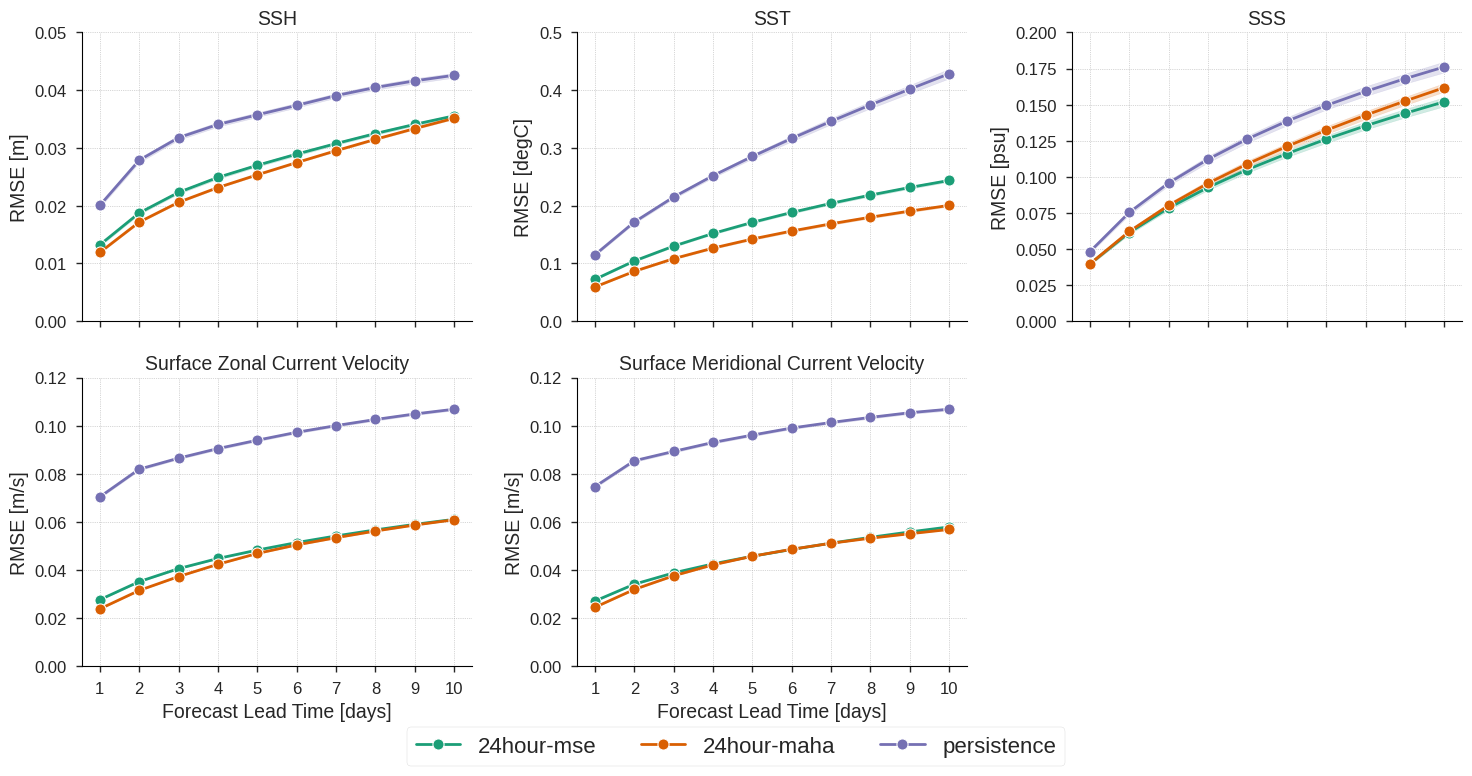

In [17]:
for truth in TRUTHS:
    print(f"--- Processing Truth: {truth} ---")

    # --- Setting up the figure axes --- 
    # Determine grid size for subplots
    n_vars = len(var_list)
    ncols = 3
    nrows = math.ceil(n_vars / ncols)
    
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, 
        figsize=(5 * ncols, 4 * nrows), 
        sharex=True
    )
    axes = axes.flatten() if n_vars > 1 else [axes]
    
    # --- Main Plotting Loop --- 
    for i, var_name in enumerate(var_list):
        ax = axes[i]
        print(f"Plotting variable: {var_name}")
        
        for config in MODELS_CONFIG:
            model_name = config["name"]
            
            # get the squared error for this model and this variable against this truth
            sqerr = all_sq_error[model_name][truth][var_name]
            
            # Calculate the RMSE data array for plotting
            rmse_to_plot = calculate_rmse(
                sqerr, 
                apply_weighting=APPLY_LATITUDE_WEIGHTING, 
                depth_level=iz_l
            )
            
            # Plot RMSE and its CI
            plot_error_vs_leadtime_seaborn(
                ax, 
                rmse_to_plot, 
                var_name=print_name[i], 
                unit=units.get(var_name, ""),
                timestep=config["timestep"],
                forecast_days=PLOT_FORECAST_DAYS,
                label=config["description"],
                ytitle="RMSE",
                vmin=error_bounds["RMSE"][var_name]["vmin"],
                vmax=error_bounds["RMSE"][var_name]["vmax"],
                apply_latitude_weighting = APPLY_LATITUDE_WEIGHTING,
            )
    
    # --- Finalize the figure (Legend and Layout) ---
    # Hide any unused subplots
    for j in range(n_vars, len(axes)):
        fig.delaxes(axes[j])
        
    # Remove individual legends from each subplot
    for ax in fig.axes:
        if ax.get_legend() is not None:
            ax.get_legend().remove()
            
    # Create a single, shared legend at the bottom
    handles, labels = fig.axes[0].get_legend_handles_labels()
    fig.legend(
        handles, 
        labels, 
        loc='lower center',
        ncol=len(MODELS_CONFIG),
        bbox_to_anchor=(0.5, 0.01)
    )
    
    # Adjust layout to make space for the title and legend
    plt.tight_layout(rect=[0, 0.05, 1, 1]) # rect=[left, bottom, right, top]
    
    # Save the figure if requested
    if SAVE_PLOT:
        figname = f"RMSE_vs_lead_time_against_{truth}.jpeg"
        if APPLY_LATITUDE_WEIGHTING:
            figname = f"LW-{figname}"
        plt.savefig(f"./figures/{figname}", dpi=300, bbox_inches='tight')
        
    plt.show()

## MAE

In [19]:
# ---- Plotting Settings ----
var_list = ["SSH", "temp", "so", "uo", "vo"] 
print_name = ["SSH", "SST", "SSS", "Surface Zonal Current Velocity", "Surface Meridional Current Velocity"]
iz_l = 0

SAVE_PLOT = False # remember to change the file name if needed
APPLY_LATITUDE_WEIGHTING = False
PLOT_FORECAST_DAYS = 10

--- Processing Truth: Replay for MAE ---
Plotting variable: SSH
Plotting variable: temp
Plotting variable: so
Plotting variable: uo
Plotting variable: vo


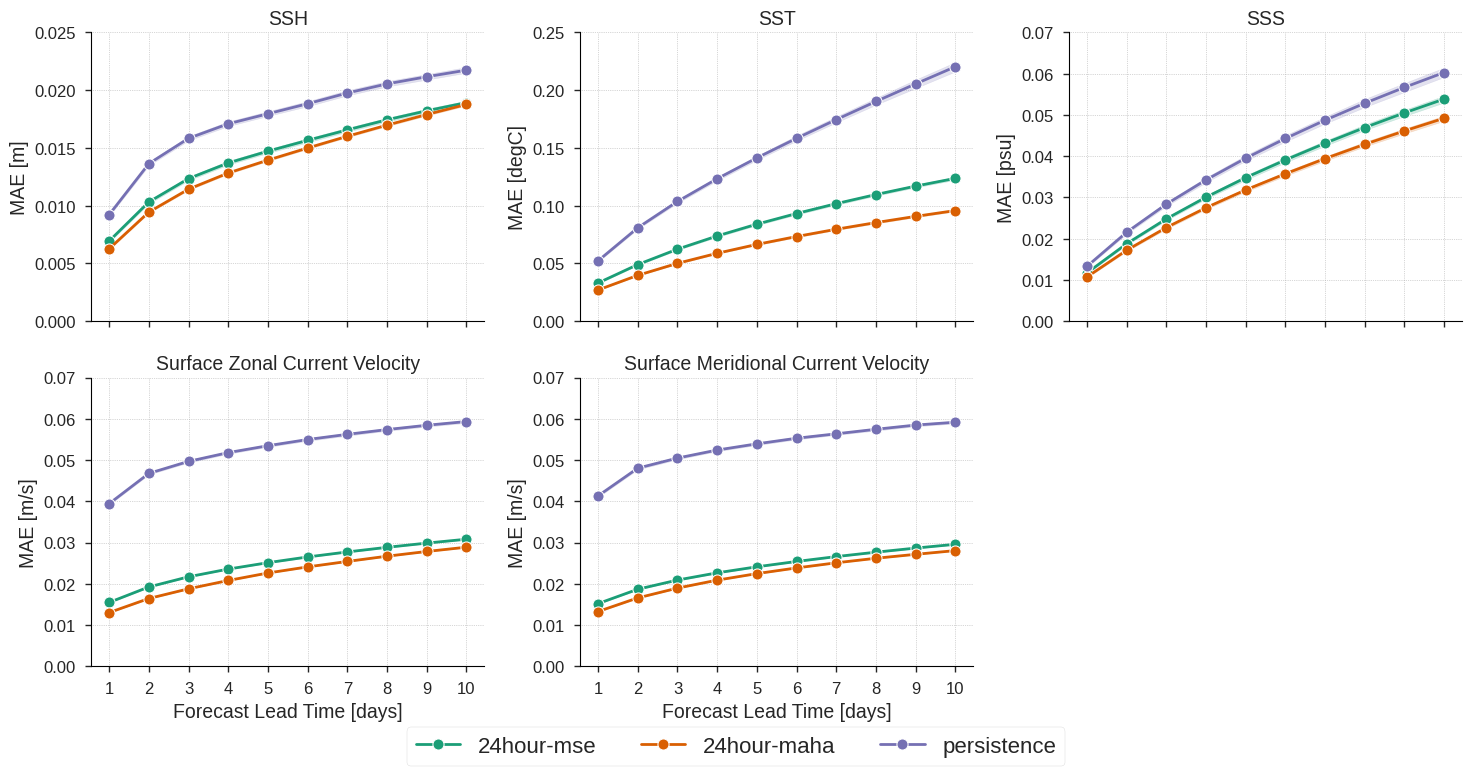

In [23]:
for truth in TRUTHS:
    print(f"--- Processing Truth: {truth} for MAE ---")

    # --- Setting up the figure axes --- 
    n_vars = len(var_list)
    ncols = 3
    nrows = math.ceil(n_vars / ncols)
    
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, 
        figsize=(5 * ncols, 4 * nrows), 
        sharex=True
    )
    axes = axes.flatten() if n_vars > 1 else [axes]
    
    # --- Main Plotting Loop --- 
    for i, var_name in enumerate(var_list):
        ax = axes[i]
        print(f"Plotting variable: {var_name}")
        
        for config in MODELS_CONFIG:
            model_name = config["name"]
            
            # Get the absolute error for this model and variable
            abserr = all_abs_error[model_name][truth][var_name]
            
            # Calculate the MAE data array for plotting
            mae_to_plot = calculate_mae(
                abserr, 
                apply_weighting=APPLY_LATITUDE_WEIGHTING, 
                depth_level=iz_l
            )
            
            # Plot MAE and its CI
            plot_error_vs_leadtime_seaborn(
                ax, 
                mae_to_plot, 
                var_name=print_name[i], 
                unit=units.get(var_name, ""),
                timestep=config["timestep"],
                forecast_days=PLOT_FORECAST_DAYS,
                label=config["description"],
                ytitle="MAE",
                vmin=error_bounds["MAE"][var_name]["vmin"],
                vmax=error_bounds["MAE"][var_name]["vmax"],
                apply_latitude_weighting=APPLY_LATITUDE_WEIGHTING,
            )
    
    # --- Finalize the figure ---
    # Hide any unused subplots
    for j in range(n_vars, len(axes)):
        fig.delaxes(axes[j])
        
    # Remove individual legends from each subplot
    for ax in fig.axes:
        if ax.get_legend() is not None:
            ax.get_legend().remove()
            
    # Create a single, shared legend at the bottom
    handles, labels = fig.axes[0].get_legend_handles_labels()
    fig.legend(
        handles, 
        labels, 
        loc='lower center',
        ncol=len(MODELS_CONFIG),
        bbox_to_anchor=(0.5, 0.01)
    )
    
    # Adjust layout to make space for the title and legend
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    
    # Save the figure if requested
    if SAVE_PLOT:
        figname = f"MAE_vs_lead_time_against_{truth}.jpeg"
        if APPLY_LATITUDE_WEIGHTING:
            figname = f"LW-{figname}"
        plt.savefig(f"./figures/{figname}", dpi=300, bbox_inches='tight')
        
    plt.show()

## ACC

In [24]:
# ---- Plotting Settings ----
var_list = ["SSH", "temp", "so", "uo", "vo"] 
print_name = ["SSH", "SST", "SSS", "Surface Zonal Current Velocity", "Surface Meridional Current Velocity"]
iz_l = 0

SAVE_PLOT = False # remember to change the file name if needed
APPLY_LATITUDE_WEIGHTING = False
PLOT_FORECAST_DAYS = 10

--- Processing Truth: Replay for ACC ---
  Plotting variable: SSH
  Plotting variable: temp
  Plotting variable: so
  Plotting variable: uo
  Plotting variable: vo


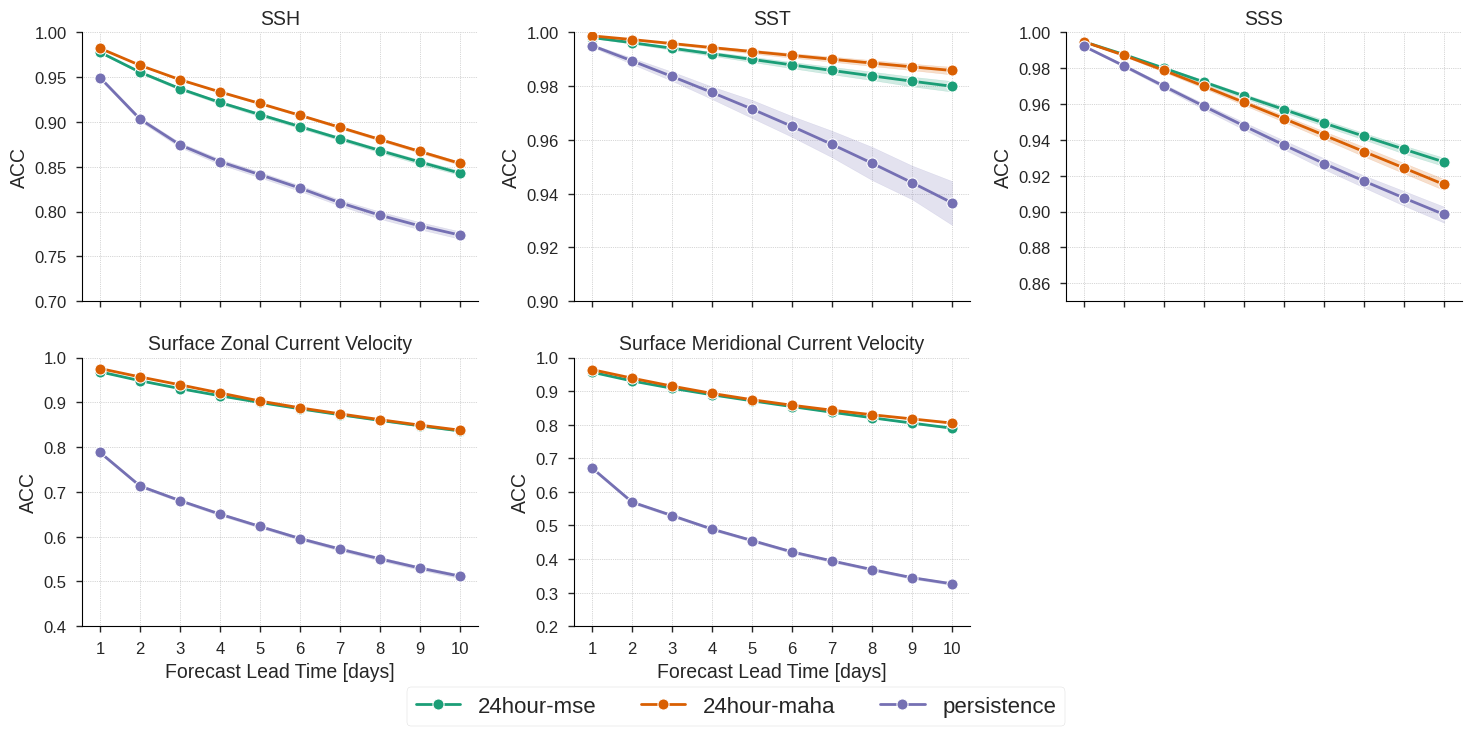

In [26]:
for truth in TRUTHS:
    print(f"--- Processing Truth: {truth} for ACC ---")

    # --- Setting up the figure axes --- 
    n_vars = len(var_list)
    ncols = 3
    nrows = math.ceil(n_vars / ncols)
    
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, 
        figsize=(5 * ncols, 4 * nrows), 
        sharex=True
    )
    axes = axes.flatten() if n_vars > 1 else [axes]
    
    # --- Main Plotting Loop --- 
    for i, var_name in enumerate(var_list):
        ax = axes[i]
        print(f"  Plotting variable: {var_name}")
        
        for config in MODELS_CONFIG:
            model_name = config["name"]
            
            # Get the pre-computed ACC data for this model and variable
            acc_to_plot = all_acc[model_name][truth][var_name]
            
            # Select depth level if the dimension exists
            if "z_l" in acc_to_plot.dims:
                acc_to_plot = acc_to_plot.isel(z_l=iz_l)

            # Plot ACC using your custom function
            plot_acc_vs_leadtime_seaborn(
                ax=ax, 
                da=acc_to_plot, 
                var_name=print_name[i], 
                unit=units.get(var_name, ""),
                timestep=config["timestep"],
                forecast_days=PLOT_FORECAST_DAYS,
                label=config["description"], # Using description for the legend label
                ytitle="ACC",  # <-- CHANGE: Set y-axis title to ACC
                vmin=error_bounds["ACC"][var_name]["vmin"],
                vmax=error_bounds["ACC"][var_name]["vmax"],
            )
    
    # --- Finalize the figure ---
    # Hide any unused subplots
    for j in range(n_vars, len(axes)):
        fig.delaxes(axes[j])
        
    # Remove individual legends from each subplot
    for ax in fig.axes:
        if ax.get_legend() is not None:
            ax.get_legend().remove()
            
    # Create a single, shared legend at the bottom
    handles, labels = fig.axes[0].get_legend_handles_labels()
    fig.legend(
        handles, 
        labels, 
        loc='lower center',
        ncol=len(MODELS_CONFIG),
        bbox_to_anchor=(0.5, 0.01)
    )
    
    # Add a title and adjust layout to make space for it and the legend
    plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # rect=[left, bottom, right, top]
    
    # Save the figure if requested
    if SAVE_PLOT:
        figname = f"ACC_vs_lead_time_against_{truth}.jpeg"
        # Note: Latitude weighting is not typically applied to ACC
        plt.savefig(f"./figures/{figname}", dpi=300, bbox_inches='tight')
        
    plt.show()

## RMSE, MAE and ACC together

In [19]:
# ---- Plotting Settings ----
var_list = ["SSH", "temp", "so", "uo", "vo"] 
print_name = ["SSH", "SST", "SSS", "Surface Zonal Current Velocity", "Surface Meridional Current Velocity"]
metrics = ["RMSE", "MAE", "ACC"]
iz_l = 0

SAVE_PLOT = True # remember to change the file name if needed
APPLY_LATITUDE_WEIGHTING = False
PLOT_FORECAST_DAYS = 10

--- Processing Truth: Replay ---

Plotting RMSE ...
Variable: SSH
Variable: temp
Variable: so
Variable: uo
Variable: vo

Plotting MAE ...
Variable: SSH
Variable: temp
Variable: so
Variable: uo
Variable: vo

Plotting ACC ...
Variable: SSH
Variable: temp
Variable: so
Variable: uo
Variable: vo


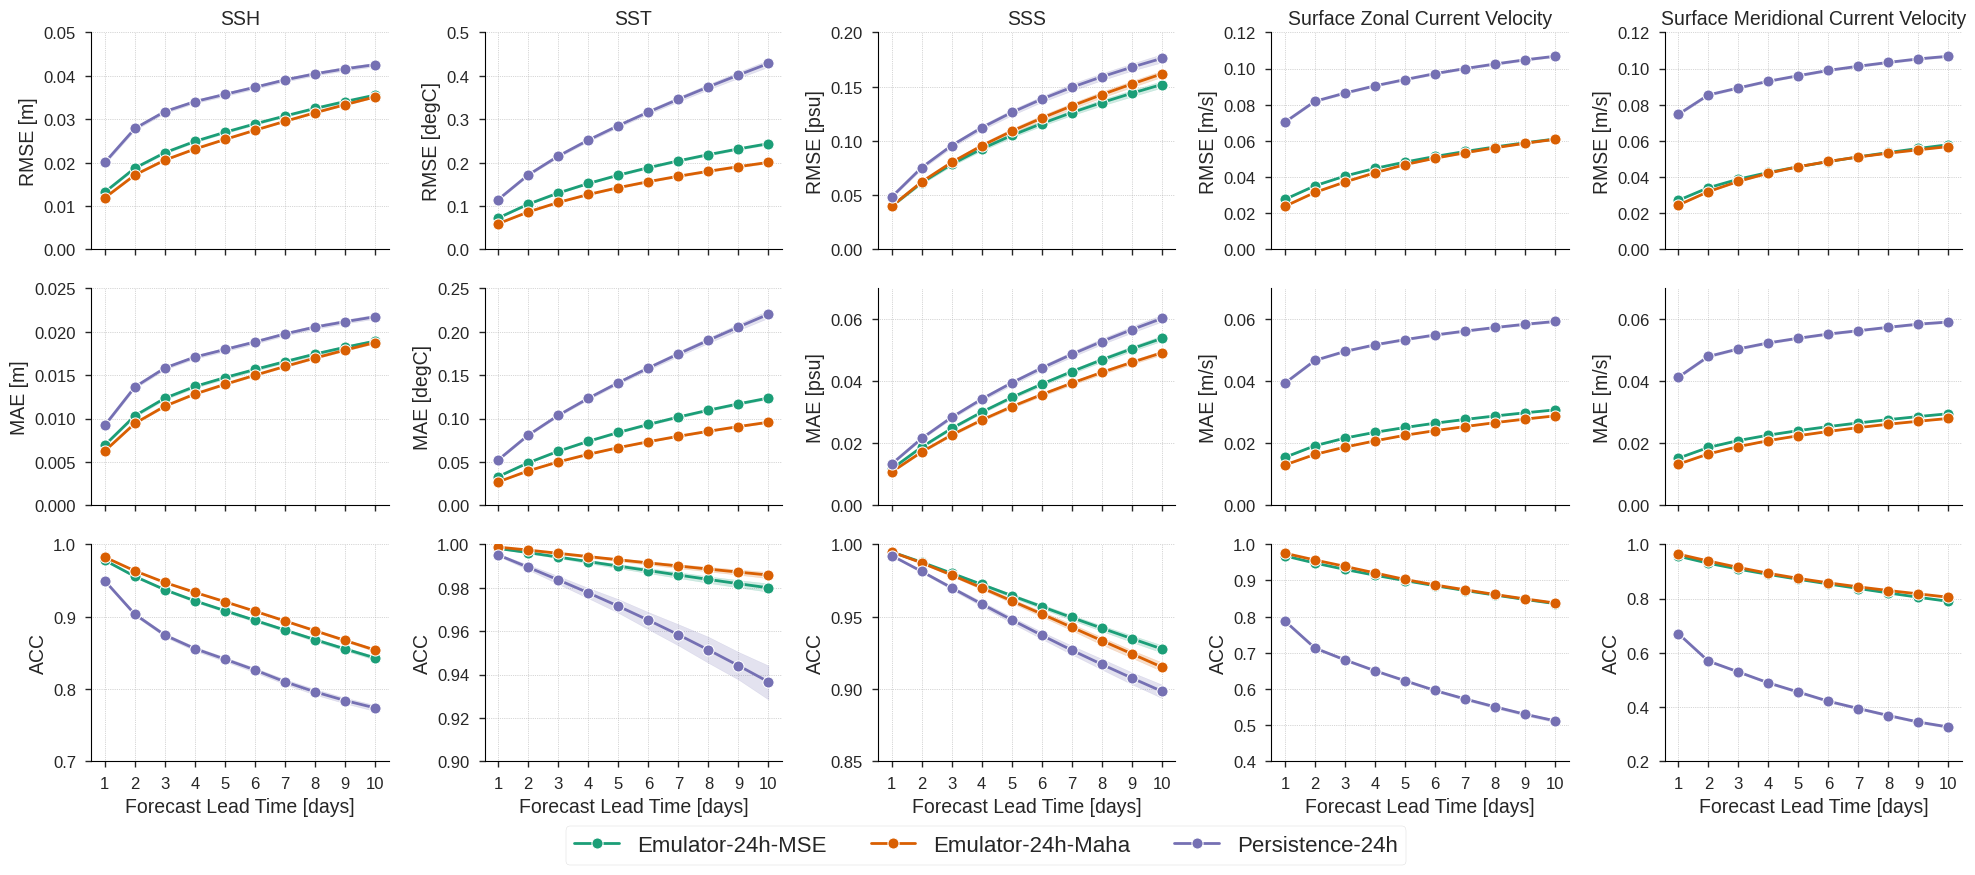

In [20]:
for truth in TRUTHS:
    print(f"--- Processing Truth: {truth} ---")

    n_vars = len(var_list)
    ncols = len(var_list)
    nrows = len(metrics)
    
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, 
        figsize=(4 * ncols, 3 * nrows), 
        sharex=True
    )
    
    # Loop through each metric (row) and variable (column)
    for j, metric in enumerate(metrics):
        print(f"\nPlotting {metric} ...")
        
        for i, var_name in enumerate(var_list):
            print(f"Variable: {var_name}")
            ax = axes[j, i]
            is_top_row = (j == 0)

            for config in MODELS_CONFIG:
                model_name = config["name"]
                data_to_plot = None

                if metric == "RMSE":
                    sqerr = all_sq_error[model_name][truth][var_name]
                    data_to_plot = calculate_rmse(sqerr, APPLY_LATITUDE_WEIGHTING, iz_l)
                    plot_error_vs_leadtime_seaborn(
                        ax, data_to_plot, var_name=print_name[i], 
                        unit=units.get(var_name, ""), timestep=config["timestep"],
                        label=model_name, ytitle=metric, show_title=is_top_row,
                        vmin=error_bounds[metric][var_name]["vmin"],
                        vmax=error_bounds[metric][var_name]["vmax"],
                        apply_latitude_weighting=APPLY_LATITUDE_WEIGHTING,
                    )
                elif metric == "MAE":
                    abserr = all_abs_error[model_name][truth][var_name]
                    data_to_plot = calculate_mae(abserr, APPLY_LATITUDE_WEIGHTING, iz_l)
                    plot_error_vs_leadtime_seaborn(
                        ax, data_to_plot, var_name=print_name[i],
                        unit=units.get(var_name, ""), timestep=config["timestep"],
                        label=model_name, ytitle=metric, show_title=is_top_row,
                        vmin=error_bounds[metric][var_name]["vmin"],
                        vmax=error_bounds[metric][var_name]["vmax"],
                        apply_latitude_weighting=APPLY_LATITUDE_WEIGHTING,
                    )
                elif metric == "ACC":
                    acc_data = all_acc[model_name][truth][var_name]
                    if "z_l" in acc_data.dims:
                        acc_data = acc_data.isel(z_l=iz_l)
                    data_to_plot = acc_data
                    plot_acc_vs_leadtime_seaborn(
                        ax, data_to_plot, var_name=print_name[i],
                        unit=units.get(var_name, ""), timestep=config["timestep"],
                        label=model_name, ytitle=metric, show_title=is_top_row,
                        vmin=error_bounds[metric][var_name]["vmin"],
                        vmax=error_bounds[metric][var_name]["vmax"]
                    )
    
    # --- 4. Finalize Figure ---
    # Remove individual legends from each subplot
    for ax in fig.axes:
        if ax.get_legend() is not None:
            ax.get_legend().remove()
            
    # Create a single, shared legend at the bottom from unique labels
    handles, labels = [], []
    for ax in fig.axes:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    
    fig.legend(
        handles, 
        labels, 
        loc='lower center',
        ncol=len(MODELS_CONFIG),
        bbox_to_anchor=(0.5, 0.01)
    )
    
    # Add a title and adjust layout
    plt.tight_layout(rect=[0, 0.05, 1, 1]) # rect=[left, bottom, right, top]
    
    # Save the figure if requested
    if SAVE_PLOT:
        figname = f"figure1.png"
        if APPLY_LATITUDE_WEIGHTING:
            figname = f"LW-{figname}"
        plt.savefig(f"./figures/{figname}", dpi=300, bbox_inches='tight')
        
    plt.show()